In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "labels.csv"
df = pd.read_csv(LABELS_PATH)

for col in ["width", "height", "file_size_bytes", "area", "aspect_ratio"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["is_downloaded_and_valid", "is_tiny", "is_suspicious_domain", "has_ui_keyword"]:
    if col in df.columns and df[col].dtype == object:
        df[col] = (
            df[col]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )

print("shape:", df.shape)
print(df["label"].value_counts(dropna=False))
print(df.columns.tolist())

shape: (527, 20)
label
content        306
non_content    221
Name: count, dtype: int64
['candidate_id', 'page_stub', 'page_url', 'image_url', 'local_path', 'domain', 'file_name', 'width', 'height', 'format', 'mode', 'file_size_bytes', 'area', 'aspect_ratio', 'is_downloaded_and_valid', 'label', 'split', 'is_tiny', 'is_suspicious_domain', 'has_ui_keyword']


## 1. Число изображений по классам

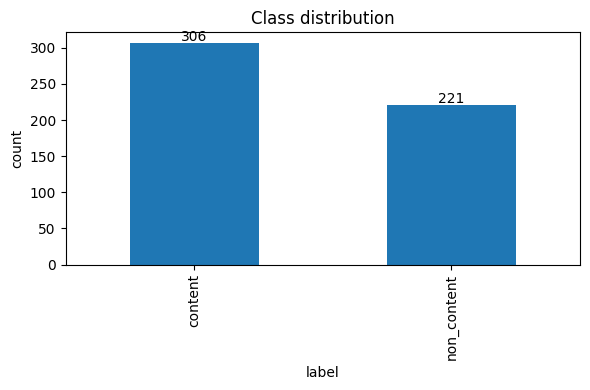

In [4]:
class_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("label")
plt.ylabel("count")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

## 2. Типичные размеры: площадь изображения

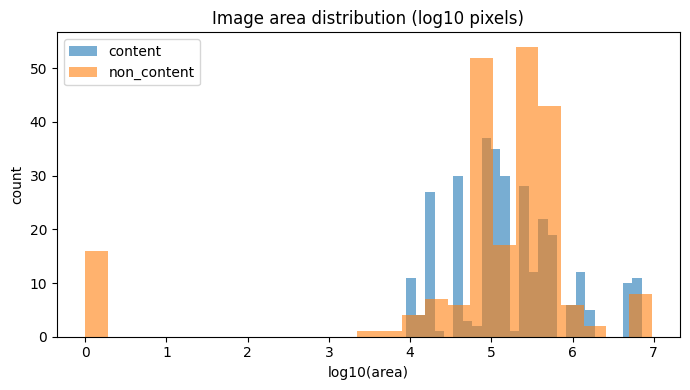

width         height              area             \
            median    mean median    mean    median       mean   
label                                                            
content      390.0  648.02  375.0  492.62  152100.0  631557.05   
non_content  480.0  541.40  450.0  487.06  230400.0  518942.30   

            file_size_bytes             
                     median       mean  
label                                   
content             31670.5  171055.42  
non_content         63085.0  129540.57

In [5]:
eda_area = df.dropna(subset=["area", "label"]).copy()
eda_area = eda_area[eda_area["area"] > 0].copy()
eda_area["log10_area"] = np.log10(eda_area["area"])

plt.figure(figsize=(7, 4))
for label in ["content", "non_content"]:
    vals = eda_area.loc[eda_area["label"] == label, "log10_area"]
    plt.hist(vals, bins=25, alpha=0.6, label=label)

plt.title("Image area distribution (log10 pixels)")
plt.xlabel("log10(area)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

display(
    df.groupby("label")[["width", "height", "area", "file_size_bytes"]]
      .agg(["median", "mean"])
      .round(2)
)

## 3. Соотношение сторон

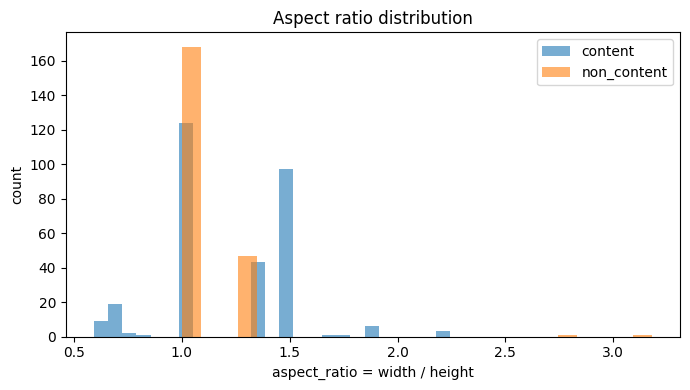

,median,mean,min,max
label,,,,
content,1.0,1.203,0.591,2.244
non_content,1.0,1.090,1.000,3.180


In [6]:
eda_ar = df.dropna(subset=["aspect_ratio", "label"]).copy()
eda_ar = eda_ar[(eda_ar["aspect_ratio"] > 0) & (eda_ar["aspect_ratio"] < 10)].copy()

plt.figure(figsize=(7, 4))
for label in ["content", "non_content"]:
    vals = eda_ar.loc[eda_ar["label"] == label, "aspect_ratio"]
    plt.hist(vals, bins=25, alpha=0.6, label=label)

plt.title("Aspect ratio distribution")
plt.xlabel("aspect_ratio = width / height")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

display(
    df.groupby("label")["aspect_ratio"]
      .agg(["median", "mean", "min", "max"])
      .round(3)
)

## 4. Форматы файлов

<Figure size 700x400 with 0 Axes>

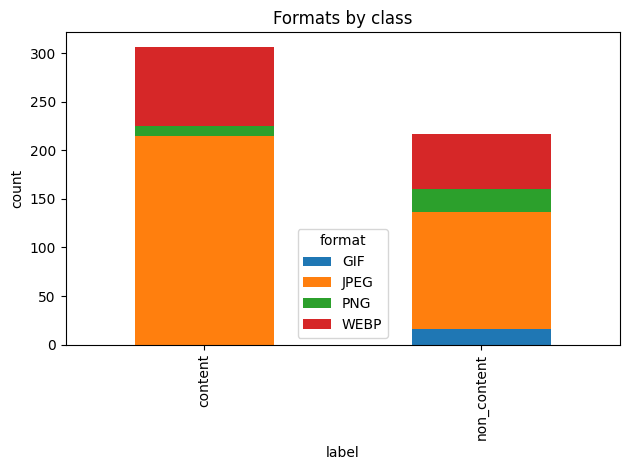

format,GIF,JPEG,PNG,WEBP
label,,,,
content,0,215,10,81
non_content,16,120,24,57


,label,format,pct
0,content,JPEG,70.3
1,content,WEBP,26.5
2,content,PNG,3.3
3,non_content,JPEG,55.3
4,non_content,WEBP,26.3
5,non_content,PNG,11.1
6,non_content,GIF,7.4


In [7]:
format_counts = df.groupby(["label", "format"]).size().unstack(fill_value=0)
format_share = (
    df.groupby("label")["format"]
      .value_counts(normalize=True)
      .mul(100)
      .round(1)
      .rename("pct")
      .reset_index()
)

plt.figure(figsize=(7, 4))
format_counts.plot(kind="bar", stacked=True)
plt.title("Formats by class")
plt.xlabel("label")
plt.ylabel("count")
plt.tight_layout()
plt.show()

display(format_counts)
display(format_share)

## 5. Очень маленькие картинки и полезные флаги

<Figure size 800x400 with 0 Axes>

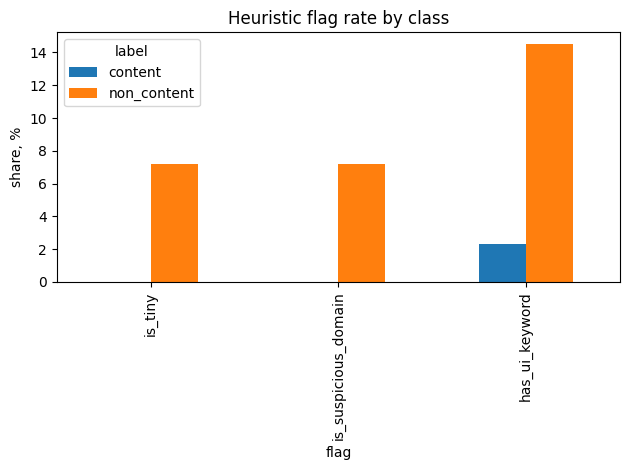

label,content,non_content
is_tiny,0.0,7.2
is_suspicious_domain,0.0,7.2
has_ui_keyword,2.3,14.5


In [8]:
flag_cols = ["is_tiny", "is_suspicious_domain", "has_ui_keyword"]
flag_cols = [c for c in flag_cols if c in df.columns]

flag_rates = df.groupby("label")[flag_cols].mean().T.mul(100).round(1)

plt.figure(figsize=(8, 4))
flag_rates.plot(kind="bar")
plt.title("Heuristic flag rate by class")
plt.xlabel("flag")
plt.ylabel("share, %")
plt.tight_layout()
plt.show()

display(flag_rates)

## 6. Повторяющиеся изображения

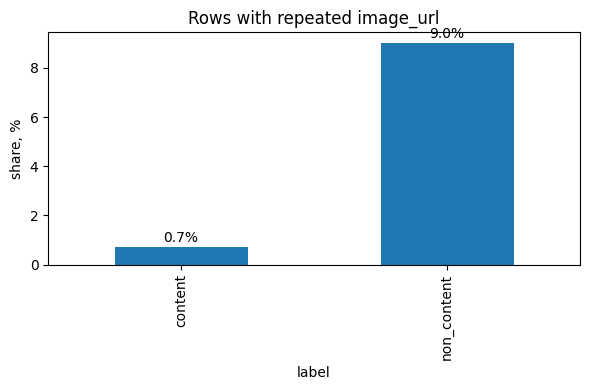

,page_stub,label,image_url,file_name,width,height
325,page_04,content,https://books.toscrape.com/media/cache/27/a5/2...,27a53d0bb95bdd88288eaf66c9230d7e.jpg,106.0,155.0
324,page_03,content,https://books.toscrape.com/media/cache/27/a5/2...,27a53d0bb95bdd88288eaf66c9230d7e.jpg,106.0,155.0
3,page_01,non_content,https://counter.rambler.ru/top100.cnt?pid=2635991,top100.cnt,1.0,1.0
146,page_02,non_content,https://counter.rambler.ru/top100.cnt?pid=2635991,top100.cnt,1.0,1.0
4,page_01,non_content,https://counter.rambler.ru/top100.cnt?pid=7728281,top100.cnt,1.0,1.0
147,page_02,non_content,https://counter.rambler.ru/top100.cnt?pid=7728281,top100.cnt,1.0,1.0
151,page_02,non_content,https://eda.rambler.ru/_next/static/images/ram...,rambler-favorites-bd704f5a077fe3675a33743723c2...,NaN,NaN
8,page_01,non_content,https://eda.rambler.ru/_next/static/images/ram...,rambler-favorites-bd704f5a077fe3675a33743723c2...,NaN,NaN
152,page_02,non_content,https://eda.rambler.ru/_next/static/images/ram...,rambler-recipes-a1c77bb63384486ec36eb950f27020...,NaN,NaN
9,page_01,non_content,https://eda.rambler.ru/_next/static/images/ram...,rambler-recipes-a1c77bb63384486ec36eb950f27020...,NaN,NaN


In [9]:
df["is_repeated_url"] = df.duplicated("image_url", keep=False)

dup_rate = df.groupby("label")["is_repeated_url"].mean().mul(100).round(1)

plt.figure(figsize=(6, 4))
dup_rate.plot(kind="bar")
plt.title("Rows with repeated image_url")
plt.xlabel("label")
plt.ylabel("share, %")
for i, v in enumerate(dup_rate.values):
    plt.text(i, v + 0.2, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

display(
    df[df["is_repeated_url"]]
    .sort_values("image_url")[["page_stub", "label", "image_url", "file_name", "width", "height"]]
    .head(20)
)